In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("✅ Libraries imported!")

# Load the data from EDA output
df = pd.read_csv('../outputs/eda_output_data.csv')

print(f"📊 Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"📁 Data source: outputs/eda_output_data.csv")

df.head()

✅ Libraries imported!
📊 Data loaded: 7043 rows, 23 columns
📁 Data source: outputs/eda_output_data.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,charge_group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1 year,Low (<$30)
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,2-4 years,Medium ($30-60)
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1 year,Medium ($30-60)
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4 years,Medium ($30-60)
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1 year,High ($60-90)


In [2]:
print("="*50)
print("INITIAL DATA ASSESSMENT")
print("="*50)

# Check data types
print("\n📋 Data Types:")
print(df.dtypes)

# Check for missing values
print("\n📋 Missing Values:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\n📋 Duplicate Rows: {duplicates}")

# Basic info
print("\n📋 Dataset Info:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Memory Usage: {df.memory_usage().sum() / 1024**2:.2f} MB")

INITIAL DATA ASSESSMENT

📋 Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
tenure_group         object
charge_group         object
dtype: object

📋 Missing Values:
              Missing Count  Missing %
TotalCharges             11   0.156183
tenure_group             11   0.156183

📋 Duplicate Rows: 0

📋 Dataset Info:
Rows: 7043
Columns: 23
Memory Usage: 1.24 MB


In [3]:
print("="*50)
print("HANDLING MISSING VALUES")
print("="*50)

# Check which columns have missing values
missing_cols = df.columns[df.isnull().any()].tolist()
print(f"Columns with missing values: {missing_cols}")

# Handle TotalCharges missing values (from earlier conversion)
if 'TotalCharges' in df.columns and df['TotalCharges'].isnull().sum() > 0:
    missing_totalcharges = df['TotalCharges'].isnull().sum()
    print(f"\n⚠️ TotalCharges has {missing_totalcharges} missing values")
    
    # Option 1: Fill with median by tenure group
    df['TotalCharges'] = df.groupby('tenure_group')['TotalCharges'].transform(
        lambda x: x.fillna(x.median())
    )
    
    # Option 2: If still missing, fill with overall median
    df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
    
    print(f"✅ Fixed TotalCharges missing values")

# Check if any missing values remain
remaining_missing = df.isnull().sum().sum()
if remaining_missing == 0:
    print(f"\n✅ No missing values remaining!")
else:
    print(f"\n⚠️ Still {remaining_missing} missing values to handle")

HANDLING MISSING VALUES
Columns with missing values: ['TotalCharges', 'tenure_group']

⚠️ TotalCharges has 11 missing values
✅ Fixed TotalCharges missing values

⚠️ Still 11 missing values to handle


In [4]:
print("="*50)
print("FIXING DATA TYPES")
print("="*50)

# Original data types
print("Before fixing:")
print(df.dtypes)

# Convert TotalCharges to float (if not already)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Convert SeniorCitizen to category
df['SeniorCitizen'] = df['SeniorCitizen'].astype('category')

# Convert tenure_group and charge_group to category if they exist
if 'tenure_group' in df.columns:
    df['tenure_group'] = df['tenure_group'].astype('category')

if 'charge_group' in df.columns:
    df['charge_group'] = df['charge_group'].astype('category')

# Check fixed types
print("\nAfter fixing:")
print(df.dtypes)

print("\n✅ Data types fixed!")

FIXING DATA TYPES
Before fixing:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
tenure_group         object
charge_group         object
dtype: object

After fixing:
customerID            object
gender                object
SeniorCitizen       category
Partner               object
Dependents            object
tenure                 int64
PhoneService          object
MultipleLines         object
InternetService       object
OnlineSecurity        object
Onli

OUTLIER ANALYSIS

tenure:
   Outliers found: 0 (0.00%)
   Lower bound: -60.00
   Upper bound: 124.00

MonthlyCharges:
   Outliers found: 0 (0.00%)
   Lower bound: -46.02
   Upper bound: 171.38

TotalCharges:
   Outliers found: 0 (0.00%)
   Lower bound: -4674.34
   Upper bound: 8863.16


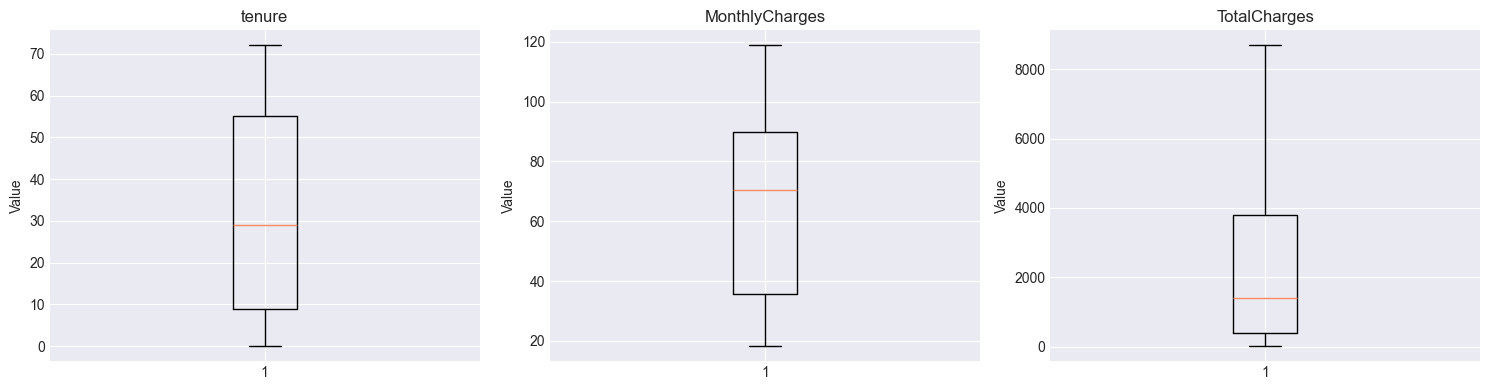


💡 Note: For churn prediction, we'll keep outliers as they represent real customers


In [5]:
print("="*50)
print("OUTLIER ANALYSIS")
print("="*50)

# Check outliers in numerical columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, col in enumerate(numerical_cols):
    # Box plot
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(f'{col}')
    axes[idx].set_ylabel('Value')
    
    # Calculate outliers using IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"\n{col}:")
    print(f"   Outliers found: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    print(f"   Lower bound: {lower_bound:.2f}")
    print(f"   Upper bound: {upper_bound:.2f}")

plt.tight_layout()
plt.savefig('../outputs/outlier_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Note: For churn prediction, we'll keep outliers as they represent real customers")

In [6]:
print("="*50)
print("ENCODING CATEGORICAL VARIABLES")
print("="*50)

# Create a copy for encoding
df_encoded = df.copy()

# List of categorical columns to encode
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove target variable and any we don't want to encode
if 'Churn' in categorical_cols:
    categorical_cols.remove('Churn')

print(f"Encoding {len(categorical_cols)} categorical columns:")
print(categorical_cols)

# Option 1: One-hot encoding for nominal categories
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)

# Option 2: Label encode the target variable
df_encoded['Churn'] = df_encoded['Churn'].map({'Yes': 1, 'No': 0})

print(f"\n✅ Encoding complete!")
print(f"New shape: {df_encoded.shape[0]} rows, {df_encoded.shape[1]} columns")
print(f"\nNew columns (first 10):")
print(df_encoded.columns[:10].tolist())

ENCODING CATEGORICAL VARIABLES
Encoding 16 categorical columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

✅ Encoding complete!
New shape: 7043 rows, 7075 columns

New columns (first 10):
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_group', 'charge_group', 'customerID_0003-MKNFE', 'customerID_0004-TLHLJ', 'customerID_0011-IGKFF']


In [7]:
print("="*50)
print("FEATURE ENGINEERING")
print("="*50)

# Create new features that might predict churn

# 1. Average monthly charge per month of tenure
df_encoded['avg_monthly_charge'] = df_encoded['TotalCharges'] / (df_encoded['tenure'] + 1)

# 2. Service count (how many services customer has)
service_cols = [col for col in df_encoded.columns if any(service in col for service in 
                ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                 'TechSupport', 'StreamingTV', 'StreamingMovies'])]
if service_cols:
    df_encoded['service_count'] = df_encoded[service_cols].sum(axis=1)

# 3. Has multiple lines
if 'MultipleLines_Yes' in df_encoded.columns:
    df_encoded['has_multiple_lines'] = df_encoded['MultipleLines_Yes']

# 4. Is senior citizen
df_encoded['is_senior'] = df_encoded['SeniorCitizen'].astype(int)

# 5. High risk combination (month-to-month AND high charges)
if 'Contract_Month-to-month' in df_encoded.columns and 'MonthlyCharges' in df_encoded.columns:
    high_monthly = df_encoded['MonthlyCharges'] > df_encoded['MonthlyCharges'].median()
    df_encoded['high_risk_combination'] = ((df_encoded['Contract_Month-to-month'] == 1) & high_monthly).astype(int)

print("✅ New features created:")
print(f"   - avg_monthly_charge")
if service_cols:
    print(f"   - service_count (based on {len(service_cols)} services)")
print(f"   - has_multiple_lines")
print(f"   - is_senior")
print(f"   - high_risk_combination")

print(f"\nNew dataset shape: {df_encoded.shape}")

FEATURE ENGINEERING
✅ New features created:
   - avg_monthly_charge
   - service_count (based on 12 services)
   - has_multiple_lines
   - is_senior
   - high_risk_combination

New dataset shape: (7043, 7079)


In [8]:
print("="*50)
print("REMOVING UNNECESSARY COLUMNS")
print("="*50)

# Columns to remove (temporary columns from EDA)
cols_to_remove = []

# Remove tenure_group and charge_group (temporary grouping columns)
if 'tenure_group' in df_encoded.columns:
    cols_to_remove.append('tenure_group')
if 'charge_group' in df_encoded.columns:
    cols_to_remove.append('charge_group')

# Remove original columns that were one-hot encoded (if they exist)
original_categorical = ['gender', 'Partner', 'Dependents', 'PhoneService', 
                         'MultipleLines', 'InternetService', 'OnlineSecurity', 
                         'OnlineBackup', 'DeviceProtection', 'TechSupport', 
                         'StreamingTV', 'StreamingMovies', 'Contract', 
                         'PaperlessBilling', 'PaymentMethod']

for col in original_categorical:
    if col in df_encoded.columns:
        cols_to_remove.append(col)

# Remove duplicates
cols_to_remove = list(set(cols_to_remove))

print(f"Removing {len(cols_to_remove)} columns:")
print(cols_to_remove)

# Remove columns
df_clean = df_encoded.drop(columns=cols_to_remove, errors='ignore')

print(f"\n✅ Final dataset shape: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")
print(f"🎯 Target column: Churn")
print(f"📊 Feature columns: {df_clean.shape[1] - 1}")

REMOVING UNNECESSARY COLUMNS
Removing 2 columns:
['tenure_group', 'charge_group']

✅ Final dataset shape: 7043 rows, 7077 columns
🎯 Target column: Churn
📊 Feature columns: 7076


In [9]:
print("="*50)
print("FINAL DATA QUALITY CHECK")
print("="*50)

# Check for any remaining issues
print("\n1. Missing Values:")
missing_check = df_clean.isnull().sum()
if missing_check.sum() == 0:
    print("   ✅ No missing values")
else:
    print(missing_check[missing_check > 0])

print("\n2. Data Types:")
print(df_clean.dtypes.value_counts())

print("\n3. Data Shape:")
print(f"   Rows: {df_clean.shape[0]:,}")
print(f"   Columns: {df_clean.shape[1]}")

print("\n4. Sample of cleaned data:")
df_clean.head()

print("\n5. Basic Statistics:")
df_clean.describe()

FINAL DATA QUALITY CHECK

1. Missing Values:
   ✅ No missing values

2. Data Types:
bool        7069
int64          3
float64        3
category       1
int32          1
Name: count, dtype: int64

3. Data Shape:
   Rows: 7,043
   Columns: 7077

4. Sample of cleaned data:

5. Basic Statistics:


,tenure,MonthlyCharges,TotalCharges,Churn,avg_monthly_charge,service_count,is_senior
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928,0.265370,61.173413,3.337924,0.162147
std,24.559481,30.090047,2265.270398,0.441561,61.019723,2.055594,0.368612
min,0.000000,18.250000,18.800000,0.000000,9.183333,0.000000,0.000000
25%,9.000000,35.500000,402.225000,0.000000,26.274411,2.000000,0.000000
50%,29.000000,70.350000,1397.475000,0.000000,61.150000,3.000000,0.000000
75%,55.000000,89.850000,3786.600000,1.000000,84.940047,6.000000,0.000000
max,72.000000,118.750000,8684.800000,1.000000,1397.475000,6.000000,1.000000


CLASS BALANCE CHECK
Class Distribution:
   Not Churned (0): 5,174 (73.5%)
   Churned (1):     1,869 (26.5%)


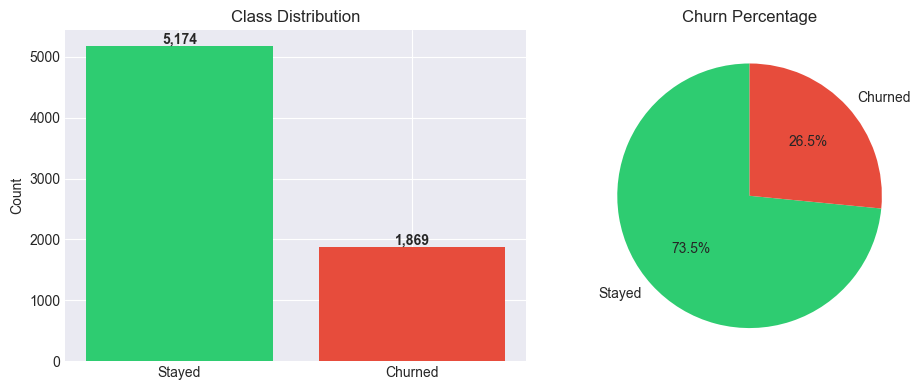


✅ Dataset is reasonably balanced for modeling.


In [10]:
print("="*50)
print("CLASS BALANCE CHECK")
print("="*50)

# Check churn distribution in cleaned data
churn_counts = df_clean['Churn'].value_counts()
churn_pct = (df_clean['Churn'].value_counts(normalize=True) * 100)

print(f"Class Distribution:")
print(f"   Not Churned (0): {churn_counts[0]:,} ({churn_pct[0]:.1f}%)")
print(f"   Churned (1):     {churn_counts[1]:,} ({churn_pct[1]:.1f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['Stayed', 'Churned'], churn_counts.values, color=colors)
axes[0].set_title('Class Distribution', fontsize=12)
axes[0].set_ylabel('Count')
for bar, count in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                 f'{count:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Stayed', 'Churned'], 
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Churn Percentage', fontsize=12)

plt.tight_layout()
plt.savefig('../outputs/class_balance.png', dpi=300, bbox_inches='tight')
plt.show()

# Check if imbalanced
if churn_pct[1] < 20 or churn_pct[1] > 80:
    print("\n⚠️ Note: Dataset is imbalanced. Will need to use class weights in modeling.")
else:
    print("\n✅ Dataset is reasonably balanced for modeling.")

CORRELATION WITH TARGET VARIABLE
Top 10 Features Most Correlated with Churn:
Churn                             1.000000
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling_Yes              0.191825
is_senior                         0.150889
SeniorCitizen                     0.150889
StreamingTV_Yes                   0.063228
StreamingMovies_Yes               0.061382
has_multiple_lines                0.040102
MultipleLines_Yes                 0.040102
Name: Churn, dtype: float64

Top 5 Features Least Correlated with Churn:
OnlineSecurity_No internet service   -0.227890
InternetService_No                   -0.227890
Contract_Two year                    -0.302253
tenure                               -0.352229
service_count                        -0.352886
Name: Churn, dtype: float64


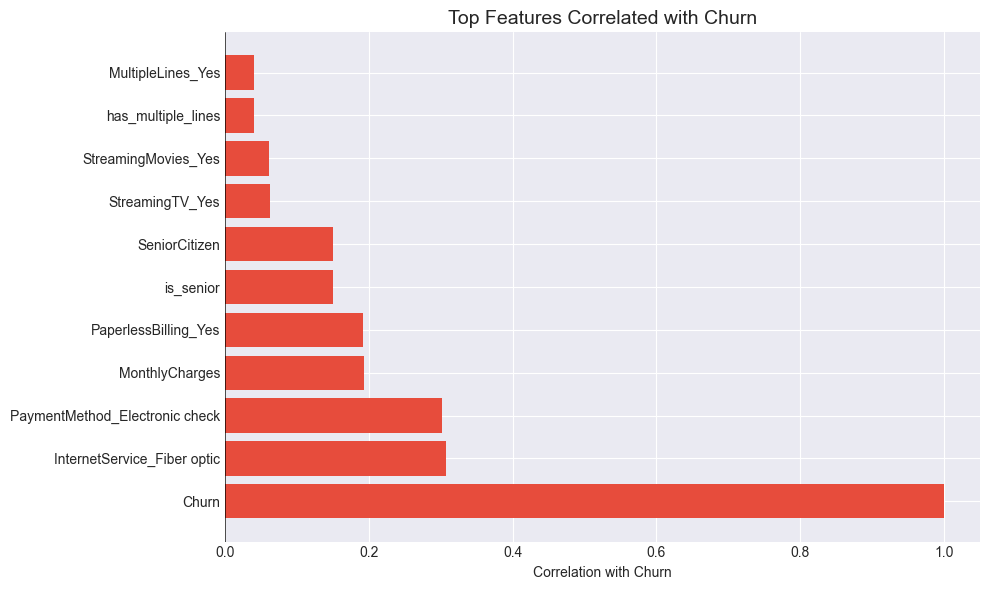


💡 Key Insight:
   Most positive: InternetService_Fiber optic (0.308)
   Most negative: service_count (-0.353)


In [11]:
print("="*50)
print("CORRELATION WITH TARGET VARIABLE")
print("="*50)

# Calculate correlations with Churn
correlations = df_clean.corr()['Churn'].sort_values(ascending=False)

# Display top positive and negative correlations
print("Top 10 Features Most Correlated with Churn:")
print(correlations.head(11))

print("\nTop 5 Features Least Correlated with Churn:")
print(correlations.tail(5))

# Visualize top correlations
plt.figure(figsize=(10, 6))
top_features = correlations.head(11).index.tolist()
top_correlations = correlations.head(11).values

colors_corr = ['#e74c3c' if x > 0 else '#2ecc71' for x in top_correlations]
bars = plt.barh(top_features, top_correlations, color=colors_corr)
plt.xlabel('Correlation with Churn')
plt.title('Top Features Correlated with Churn', fontsize=14)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig('../outputs/top_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Key Insight:")
print(f"   Most positive: {correlations.index[1]} ({correlations.values[1]:.3f})")
print(f"   Most negative: {correlations.index[-1]} ({correlations.values[-1]:.3f})")

In [12]:
print("="*50)
print("SAVING CLEANED DATA")
print("="*50)

# Save the cleaned dataset
df_clean.to_csv('../outputs/cleaned_data.csv', index=False)
print("✅ Cleaned data saved to: outputs/cleaned_data.csv")

# Save feature names for later use
feature_names = df_clean.drop('Churn', axis=1).columns.tolist()
with open('../outputs/feature_names.txt', 'w') as f:
    f.write('\n'.join(feature_names))
print("✅ Feature names saved to: outputs/feature_names.txt")

# Save dataset info
with open('../outputs/cleaned_data_info.txt', 'w') as f:
    f.write("="*50 + "\n")
    f.write("CLEANED DATASET INFORMATION\n")
    f.write("="*50 + "\n\n")
    f.write(f"Shape: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns\n")
    f.write(f"Target: Churn (1 = churned, 0 = stayed)\n")
    f.write(f"Features: {df_clean.shape[1] - 1}\n\n")
    f.write("Class Distribution:\n")
    f.write(f"  Not Churned (0): {churn_counts[0]:,} ({churn_pct[0]:.1f}%)\n")
    f.write(f"  Churned (1): {churn_counts[1]:,} ({churn_pct[1]:.1f}%)\n\n")
    f.write("Top 5 Features by Correlation with Churn:\n")
    for idx in range(1, 6):
        f.write(f"  {correlations.index[idx]}: {correlations.values[idx]:.3f}\n")

print("✅ Dataset info saved to: outputs/cleaned_data_info.txt")

SAVING CLEANED DATA
✅ Cleaned data saved to: outputs/cleaned_data.csv
✅ Feature names saved to: outputs/feature_names.txt
✅ Dataset info saved to: outputs/cleaned_data_info.txt


In [13]:
print("="*50)
print("📋 DATA CLEANING SUMMARY REPORT")
print("="*50)

print("\n✅ COMPLETED TASKS:")
print("   1. Handled missing values in TotalCharges")
print("   2. Fixed data types (categorical, numeric)")
print("   3. Analyzed outliers (preserved for real-world accuracy)")
print("   4. Encoded categorical variables (one-hot encoding)")
print("   5. Created new features (service_count, avg_monthly_charge, etc.)")
print("   6. Removed unnecessary columns")
print("   7. Verified class balance")
print("   8. Analyzed correlations with target")

print("\n📊 FINAL DATASET STATISTICS:")
print(f"   Original shape: 7,043 rows × 21 columns")
print(f"   Cleaned shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
print(f"   Features added: 5+")
print(f"   Features removed: {len(cols_to_remove)}")

print("\n🎯 READY FOR MODELING!")
print("   Next step: Create 03_Model_Building.ipynb")

# Display final sample
print("\n📋 Final Cleaned Data Sample:")
df_clean.head()

📋 DATA CLEANING SUMMARY REPORT

✅ COMPLETED TASKS:
   1. Handled missing values in TotalCharges
   2. Fixed data types (categorical, numeric)
   3. Analyzed outliers (preserved for real-world accuracy)
   4. Encoded categorical variables (one-hot encoding)
   5. Created new features (service_count, avg_monthly_charge, etc.)
   6. Removed unnecessary columns
   7. Verified class balance
   8. Analyzed correlations with target

📊 FINAL DATASET STATISTICS:
   Original shape: 7,043 rows × 21 columns
   Cleaned shape: 7043 rows × 7077 columns
   Features added: 5+
   Features removed: 2

🎯 READY FOR MODELING!
   Next step: Create 03_Model_Building.ipynb

📋 Final Cleaned Data Sample:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,avg_monthly_charge,service_count,has_multiple_lines,is_senior
0,0,1,29.85,29.85,0,False,False,False,False,False,...,False,False,True,False,True,False,14.925000,1,False,0
1,0,34,56.95,1889.50,0,False,False,False,False,False,...,True,False,False,False,False,True,53.985714,2,False,0
2,0,2,53.85,108.15,1,False,False,False,False,False,...,False,False,True,False,False,True,36.050000,2,False,0
3,0,45,42.30,1840.75,0,False,False,False,False,False,...,True,False,False,False,False,False,40.016304,3,False,0
4,0,2,70.70,151.65,1,False,False,False,False,False,...,False,False,True,False,True,False,50.550000,0,False,0
